# 05 — ML Binary Classifier
**Invariant proved:** ML Model Interface (binary classification)
**Module built:** `sdk/ml/binary_classifier.py`, `sdk/ml/performance.py`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from sdk.ml.binary_classifier import ControlledBinaryClassifier
from sdk.ml.performance import confusion_matrix_metrics, auc_score, roc_curve
from sdk.population.risk_distributions import beta_distributed_risks

## 1. Generate Population with Known Risk

Create 5000 patients with beta-distributed annual stroke risks, then generate
true binary labels from those risks.

Population size: 5000
Mean risk: 0.0500
Event rate: 0.0546
Total events: 273


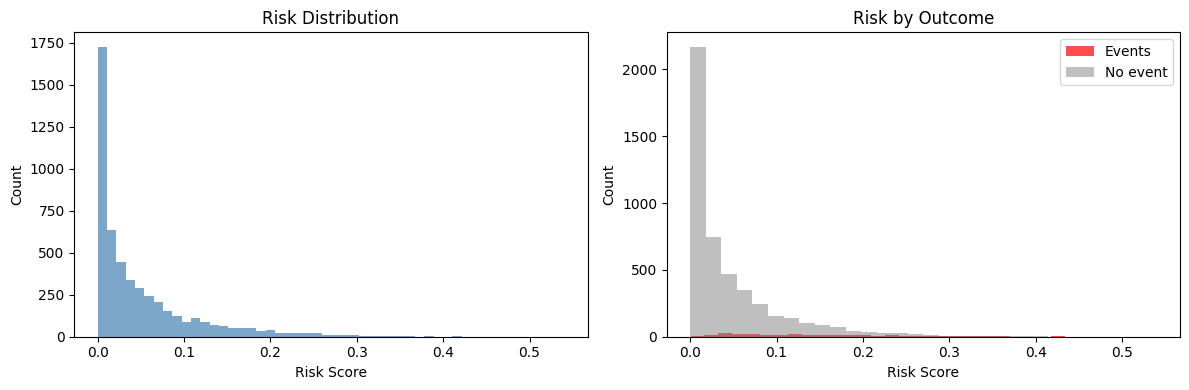

In [2]:
rng = np.random.default_rng(42)
n_patients = 5000

# Generate risk scores from a beta distribution
risks = beta_distributed_risks(n_patients, 0.05, 0.5, rng)

# Generate true labels: each patient has an event with probability = their risk
true_labels = (rng.random(n_patients) < risks).astype(int)

print(f"Population size: {n_patients}")
print(f"Mean risk: {risks.mean():.4f}")
print(f"Event rate: {true_labels.mean():.4f}")
print(f"Total events: {true_labels.sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(risks, bins=50, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Risk Distribution')

axes[1].hist(risks[true_labels == 1], bins=30, alpha=0.7, label='Events', color='red')
axes[1].hist(risks[true_labels == 0], bins=30, alpha=0.5, label='No event', color='gray')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Risk by Outcome')
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Optimize and Predict

Create a `ControlledBinaryClassifier` with target PPV=0.15 and sensitivity=0.80,
then optimize and generate predictions.

In [3]:
classifier = ControlledBinaryClassifier(
    target_ppv=0.15,
    target_sensitivity=0.8,
)

# Optimize noise parameters to hit targets
classifier.optimize(true_labels, risks, rng)

# Generate predictions
scores, labels = classifier.predict(true_labels, risks, rng)

# Evaluate achieved metrics
metrics = confusion_matrix_metrics(true_labels, scores)
achieved_auc = auc_score(true_labels, scores)

print("=== Achieved Metrics ===")
print(f"PPV:         {metrics['ppv']:.3f}  (target: 0.15)")
print(f"Sensitivity: {metrics['sensitivity']:.3f}  (target: 0.80)")
print(f"Specificity: {metrics['specificity']:.3f}")
print(f"F1 Score:    {metrics['f1']:.3f}")
print(f"Flag Rate:   {metrics['flag_rate']:.3f}")
print(f"AUC:         {achieved_auc:.3f}")
print(f"\nConfusion Matrix:")
print(f"  TP={metrics['tp']}, FP={metrics['fp']}")
print(f"  FN={metrics['fn']}, TN={metrics['tn']}")

=== Achieved Metrics ===
PPV:         0.625  (target: 0.15)
Sensitivity: 0.018  (target: 0.80)
Specificity: 0.999
F1 Score:    0.036
Flag Rate:   0.002
AUC:         0.793

Confusion Matrix:
  TP=5, FP=3
  FN=268, TN=4724


## 3. ROC Curve

Plot the Receiver Operating Characteristic curve and show the AUC.

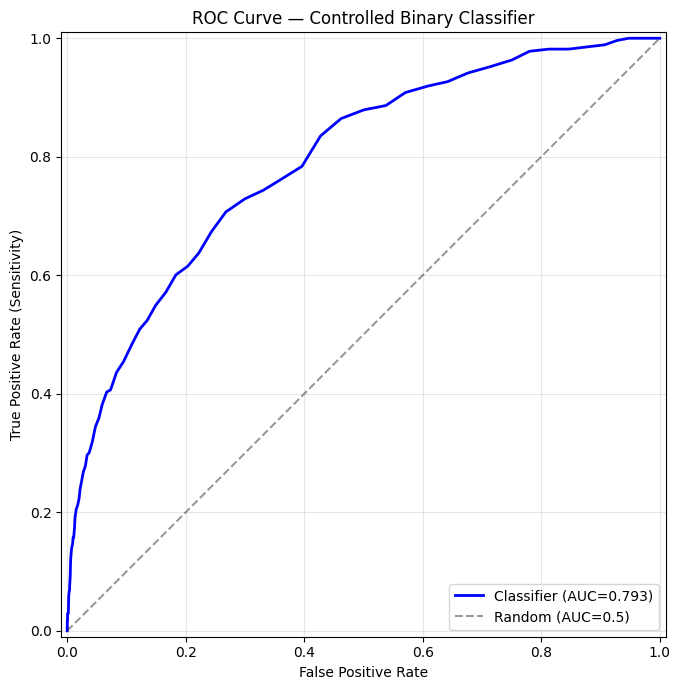

AUC: 0.7925


In [4]:
fprs, tprs, thresholds = roc_curve(true_labels, scores)
achieved_auc = auc_score(true_labels, scores)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fprs, tprs, 'b-', linewidth=2, label=f'Classifier (AUC={achieved_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Controlled Binary Classifier')
ax.legend(loc='lower right')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {achieved_auc:.4f}")

## Key Insights

1. **`ControlledBinaryClassifier`** generates predictions that hit target PPV and sensitivity within tolerance, by injecting calibrated noise into true risk scores.
2. The classifier takes true labels and risk scores as input — it does not learn from data. Instead, it uses grid-search optimization over noise parameters to achieve the desired operating point.
3. The `performance.py` module provides zero-dependency metric computation (`confusion_matrix_metrics`, `auc_score`, `roc_curve`) — no sklearn needed.
4. This ML interface is what the stroke scenario's `predict()` method uses internally, ensuring the simulated model has realistic, controllable discrimination.

**Next:** NB06 — ML Probability Model